In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models

import numpy as np
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit

import kagglehub

from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


class FER2013CNN(nn.Module):
    def __init__(self, num_classes=7, lr=1e-4, epochs=30):
        super(FER2013CNN, self).__init__()

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        class ResidualBlock(nn.Module):
            def __init__(self, channels):
                super().__init__()
                self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
                self.bn1 = nn.BatchNorm2d(channels)
                self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
                self.bn2 = nn.BatchNorm2d(channels)
                self.relu = nn.ReLU()

            def forward(self, x):
                identity = x
                out = self.relu(self.bn1(self.conv1(x)))
                out = self.bn2(self.conv2(out))
                return self.relu(identity + out)

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualBlock(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            ResidualBlock(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            ResidualBlock(256),
            ResidualBlock(256),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=lr, weight_decay=1e-4)

        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=epochs
        )

        self.to(self.device)

    def forward(self, x):
        x = x.to(self.device)
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _loss_(self, outputs, targets, class_weights=None):
        targets = targets.to(self.device)

        if class_weights is not None:
            class_weights = class_weights.to(self.device)
            loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
        else:
            loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

        return loss_fn(outputs, targets)

    def train_(self, train_loader, epochs=30, class_weights=None, val_loader=None):
        best_val_acc = 0
        for epoch in range(epochs):
            self.train()
            total_train_loss = 0

            for x, targets in train_loader:
                x, targets = x.to(self.device), targets.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.forward(x)
                loss = self._loss_(outputs, targets, class_weights)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), 5.0)
                self.optimizer.step()

                total_train_loss += loss.item()

            avg_train_loss = total_train_loss / len(train_loader)

            if val_loader is not None:
                self.eval()
                total_val_loss = 0
                correct = 0
                total = 0

                with torch.no_grad():
                    for x_val, targets_val in val_loader:
                        x_val, targets_val = x_val.to(self.device), targets_val.to(self.device)
                        outputs_val = self.forward(x_val)

                        val_loss = self._loss_(outputs_val, targets_val, class_weights)
                        total_val_loss += val_loss.item()

                        _, predicted = torch.max(outputs_val, 1)
                        total += targets_val.size(0)
                        correct += (predicted == targets_val).sum().item()

                avg_val_loss = total_val_loss / len(val_loader)
                val_acc = correct / total

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(self.state_dict(), "best_model.pth")

                print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
                self.scheduler.step()
            else:
                print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f}")
        self.load_state_dict(torch.load("best_model.pth"))

    def test_(self, data_loader):
        self.eval()
        correct = 0
        total = 0

        all_preds, all_targets, all_logits = [], [], []

        with torch.no_grad():
            for x, targets in data_loader:
                x, targets = x.to(self.device), targets.to(self.device)
                outputs = self.forward(x)

                _, predicted = torch.max(outputs, 1)

                total += targets.size(0)
                correct += (predicted == targets).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_logits.extend(outputs.cpu().numpy())

        return correct / total, np.array(all_preds), np.array(all_targets), np.array(all_logits)

In [ ]:
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [ ]:
import shutil
import os

target_dir = "/content/fer2013"
os.makedirs(target_dir, exist_ok=True)

# Copy dataset over to content cache
for item_name in os.listdir(path):
  source_path = os.path.join(path, item_name)
  destination_path = os.path.join(target_dir, item_name)
  if os.path.isdir(source_path):
    shutil.copytree(source_path, destination_path)
  else:
    shutil.copy(source_path, destination_path)


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
path = os.getcwd()

dataset_for_split = datasets.ImageFolder(os.path.join(path, 'fer2013/train'))
targets = np.array(dataset_for_split.targets)

num_classes = len(dataset_for_split.classes)
print('Dataset classes:', dataset_for_split.classes)

# Perform 80/20 train-validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_dataset = datasets.ImageFolder(os.path.join(path, 'fer2013/train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(path, 'fer2013/train'), transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_idx))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(val_idx))

from collections import Counter
train_targets = targets[train_idx]
class_counts = Counter(train_targets)
total_samples = sum(class_counts.values())
weights = torch.zeros(num_classes, dtype=torch.float32)

for i in range(num_classes):
    if class_counts[i] > 0:
        weights[i] = total_samples / (num_classes * class_counts[i])
    else:
        weights[i] = 0.0

class_weights = weights

print("Class counts (training set):", class_counts)
print("Weights per class (training set):", class_weights)


Dataset classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class counts (training set): Counter({np.int64(3): 5772, np.int64(4): 3972, np.int64(5): 3864, np.int64(2): 3277, np.int64(0): 3196, np.int64(6): 2537, np.int64(1): 349})
Weights per class (training set): tensor([1.0266, 9.4011, 1.0012, 0.5684, 0.8260, 0.8491, 1.2933])


Training and validation dataloaders have been created with an 80/20 train-validation split.

In [ ]:
for x in range(len(class_weights)):
    print(f"{dataset_for_split.classes[x]} weight:\t{class_weights[x]:.4f}")

angry weight:	1.0266
disgust weight:	9.4011
fear weight:	1.0012
happy weight:	0.5684
neutral weight:	0.8260
sad weight:	0.8491
surprise weight:	1.2933


In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
model = FER2013CNN(num_classes=num_classes, lr=LEARNING_RATE)

print('Training CNN model...')
model.train_(train_loader, epochs=EPOCHS, class_weights=class_weights, val_loader=val_loader)

Training CNN model...
Epoch [1/100] Train Loss: 2.1468 | Val Loss: 2.1355 | Val Acc: 0.0920
Epoch [2/100] Train Loss: 2.0848 | Val Loss: 2.1495 | Val Acc: 0.0381
Epoch [3/100] Train Loss: 2.0371 | Val Loss: 1.9532 | Val Acc: 0.1461
Epoch [4/100] Train Loss: 1.9678 | Val Loss: 2.0925 | Val Acc: 0.3046
Epoch [5/100] Train Loss: 1.9079 | Val Loss: 1.8592 | Val Acc: 0.2421
Epoch [6/100] Train Loss: 1.8690 | Val Loss: 1.8046 | Val Acc: 0.3694
Epoch [7/100] Train Loss: 1.8319 | Val Loss: 1.7759 | Val Acc: 0.3633
Epoch [8/100] Train Loss: 1.8118 | Val Loss: 1.7684 | Val Acc: 0.4432
Epoch [9/100] Train Loss: 1.7912 | Val Loss: 1.7321 | Val Acc: 0.4316
Epoch [10/100] Train Loss: 1.7705 | Val Loss: 1.7892 | Val Acc: 0.4523
Epoch [11/100] Train Loss: 1.7556 | Val Loss: 1.6859 | Val Acc: 0.4354
Epoch [12/100] Train Loss: 1.7386 | Val Loss: 1.6817 | Val Acc: 0.4288
Epoch [13/100] Train Loss: 1.7199 | Val Loss: 1.6655 | Val Acc: 0.4902
Epoch [14/100] Train Loss: 1.7030 | Val Loss: 1.7104 | Val Acc: 

In [ ]:
torch.save(model.state_dict(), "model_weights.pth")

In [ ]:
path = os.getcwd()
test_dataset = datasets.ImageFolder(os.path.join(path, 'fer2013/test'), transform=val_transform)

num_test_classes = len(test_dataset.classes)
print('Test Dataset classes:', test_dataset.classes)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

Test Dataset classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


  Test Accuracy : 0.6818
  F1 Score      : 0.6808
  Precision     : 0.6823
  Recall        : 0.6818


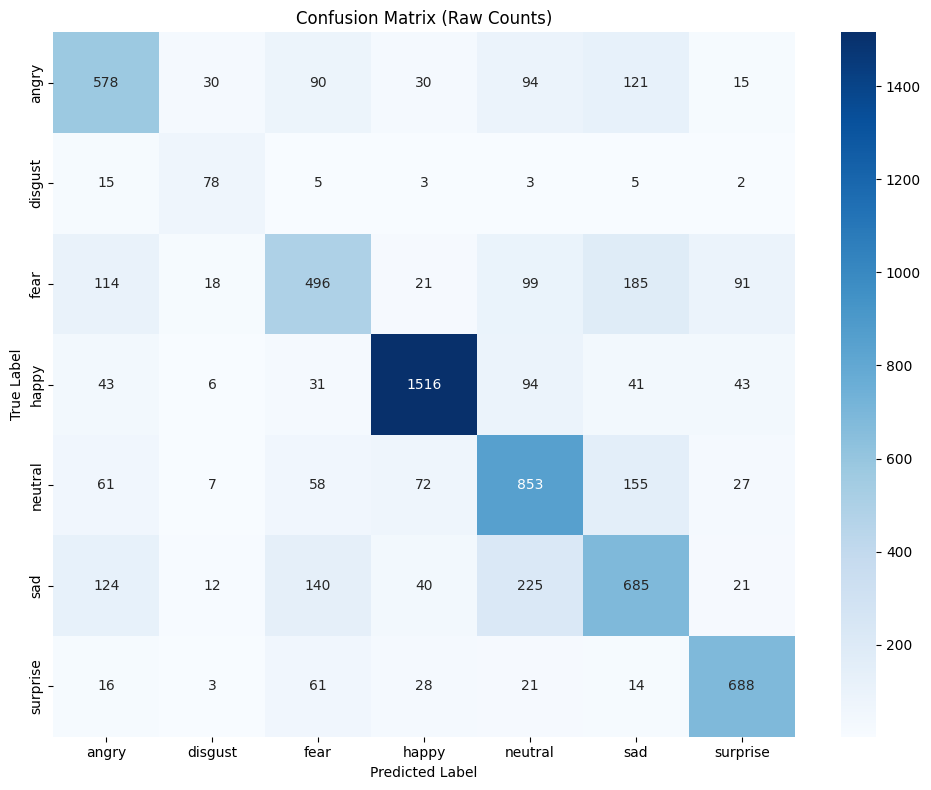

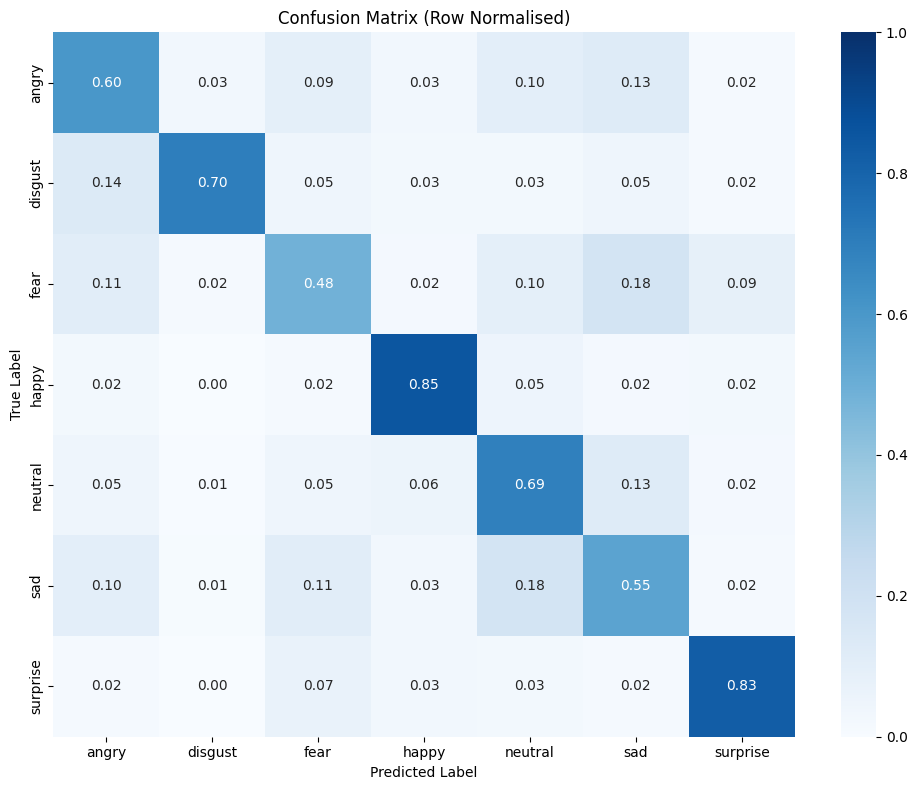

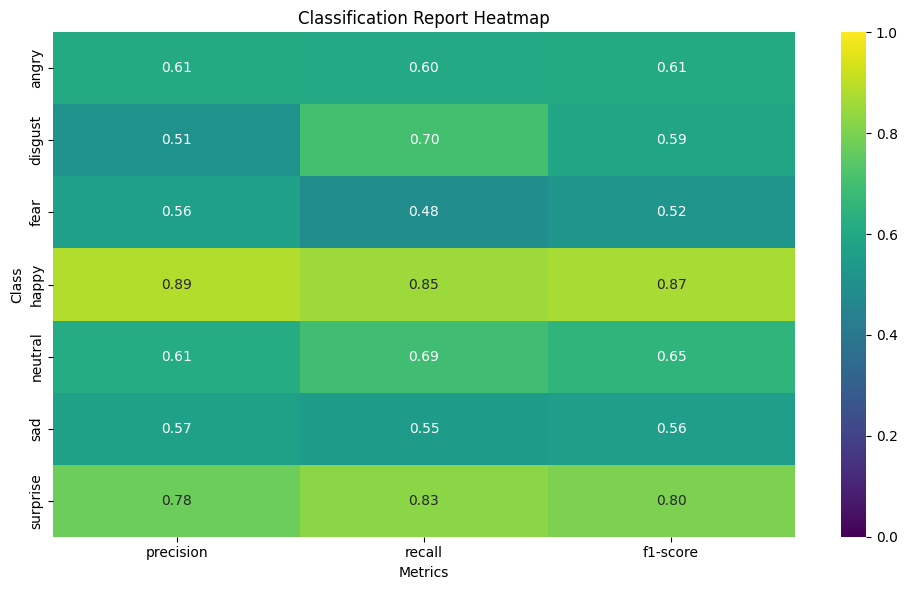

In [ ]:
# Evaluate the model
accuracy, all_predicted, all_targets, all_outputs = model.test_(test_loader)
class_names = test_dataset.classes

# Overall metrics
f1        = f1_score(all_targets, all_predicted, average='weighted')
precision = precision_score(all_targets, all_predicted, average='weighted')
recall    = recall_score(all_targets, all_predicted, average='weighted')

print("=" * 40)
print(f"  Test Accuracy : {accuracy:.4f}")
print(f"  F1 Score      : {f1:.4f}")
print(f"  Precision     : {precision:.4f}")
print(f"  Recall        : {recall:.4f}")
print("=" * 40)

cm = confusion_matrix(all_targets, all_predicted)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Raw count confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Raw Counts)')
plt.tight_layout()
plt.show()

# Row-normalised confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Row Normalised)')
plt.tight_layout()
plt.show()

# Classification report heatmap
report_dict = classification_report(all_targets, all_predicted, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.drop(columns=['support'])
report_df = report_df.loc[class_names]

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='viridis', fmt='.2f', vmin=0, vmax=1)
plt.title('Classification Report Heatmap')
plt.ylabel('Class')
plt.xlabel('Metrics')
plt.tight_layout()
plt.show()